# Telco Customer Churn — Modeling & Evaluation

**Author:** Allison Schiltz\

**Objectives**:
- Build two models to predict `Churn`:
    - For both models: **Class weights** will be used adjust for imbalanced data and **regularization** will be used to prevent overfitting.
    - **Logistic Regression** with regularizataion as a baseline and for interpretability. A baseline model helps determine whether a more complex model adds value. 
    - **Gradient Boosted Trees** using LightGBM for higher predictive power
    - **Optuna** will be using for hyperparameter tuning and cross-validation
- **Strategy**: 
    - Use a train/test split strategy with cross-validation (CV) plus a final holdout set.
    - Perform cross-validation on the training data to tune hyperparameters.
    - Evaluate the final model on the untouched test set (holdout) for an unbiased performance estimate.
- Prioritize **recall ≥ 0.70** and **ROC-AUC > 0.75**
    - **Recall** to identify as many customers at risk of churning as possible (minimizing false negatives). This is important in churn scenarios, where missing a potential churner can be costly for the business.
    - **ROC-AUC** to measure the model’s overall discriminative power to distinguish between churners and non-churners across all thresholds.

## 0. Environment & Imports

In [41]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import optuna.integration.lightgbm as lgb_optuna

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import recall_score, roc_auc_score, precision_score, confusion_matrix, roc_curve, precision_recall_curve, make_scorer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict

import lightgbm as lgb

SEED = 42
np.random.seed(SEED)

In [42]:
import sys
print(sys.executable)

/Users/Allison/Code/.venv/bin/python


## 1. Load Data
- Load combined, preprocessed features and target labels needed for modeling.
- Load column-role manifest (ID, target, numeric, categorical, booleans)

In [43]:
# Load Training features
X_train_final = pd.read_csv('../data/processed/X_train_final.csv')
# Load Training target
y_train = pd.read_csv('../data/processed/y_train.csv')

# Load Test features
X_test_final = pd.read_csv('../data/processed/X_test_final.csv')
# Load Test target
y_test = pd.read_csv('../data/processed/y_test.csv')

# Load column role manifest
column_roles = pd.read_csv('../references/telco_column_role_manifest.csv')

# Load pruned feature sets based on EDA findings
pruned_features_monthly_charges_bin = pd.read_csv('../data/processed/pruned_features_monthly_charges_bin.csv', header=None).squeeze().tolist()

pruned_features_internet_service = pd.read_csv('../data/processed/pruned_features_internet_service.csv', header=None).squeeze().tolist()

pruned_features_all_add_ons = pd.read_csv('../data/processed/pruned_features_all_add_ons.csv', header=None).squeeze().tolist()

In [44]:
# Clean column names to remove special JSON characters for LightGBM compatibility
import re

def clean_lgbm_feature_names(df):
    df = df.copy()
    df.columns = [
        re.sub(r'["\\{}\[\]:,]', '_', str(col)) for col in df.columns
    ]
    return df

# Cleaned versions for LightGBM
X_train_final_clean = clean_lgbm_feature_names(X_train_final)
X_test_final_clean = clean_lgbm_feature_names(X_test_final)


In [45]:
# Extract target column

y_train = y_train['Churn']
y_test = y_test['Churn']

In [46]:
print(X_train_final_clean.shape)
print(y_train.shape, '\n')

print(X_test_final_clean.shape)
print(y_test.shape)

(5625, 41)
(5625,) 

(1407, 41)
(1407,)


In [47]:
print(X_train_final_clean.head())
print(X_test_final_clean.head())
print(y_train.head())
print(y_test.head(), '\n')
print('X_train_final_clean dtypes:', X_train_final_clean.dtypes, '\n')
print('X_test_final_clean dtypes:', X_test_final_clean.dtypes, '\n')

   Unnamed_ 0    tenure  MonthlyCharges  TotalCharges  total_services_eng  \
0        1408  1.321816        0.981556      1.659900            1.269948   
1        6992 -0.267410       -0.971546     -0.562252           -0.671868   
2        3349  1.444064        0.837066      1.756104            0.784494   
3        4486 -1.204646        0.641092     -0.908326           -0.186414   
4        3535  0.669826       -0.808787     -0.101561           -0.671868   

   gender_Male  SeniorCitizen_Yes  Partner_Yes  Dependents_Yes  \
0         True              False         True            True   
1         True              False        False           False   
2        False              False         True           False   
3         True              False        False           False   
4        False              False         True           False   

   PhoneService_Yes  ...  PaymentMethod_Mailed_check  tenure_group_eng_13-24  \
0              True  ...                       False        

## 2. Baselines
1. Majority-class baseline:
- Predict the most frequent class for all cases (e.g., always predict "No Churn").
- Calculate and record metrics: recall, precision, ROC-AUC, PR-AUC. This sets a minimum performance bar.
2. Logistic regression baseline (with regularization):
- Train a logistic regression model using default or simple regularization (e.g., L2 penalty, class_weight="balanced").
- Evaluate on the validation or test set.
- Record the same metrics: recall, precision, ROC-AUC, PR-AUC.


### Majority class baseline: all features

In [48]:
# Majority class baseline with all features
from sklearn.dummy import DummyClassifier

# Instantiate and fit dummy classifier
dummy = DummyClassifier(strategy="stratified", random_state=SEED)
dummy.fit(X_train_final_clean, y_train.values.ravel())

# Predict class labels and class probabilities
y_pred_dummy = dummy.predict(X_test_final_clean)
y_proba_dummy = dummy.predict_proba(X_test_final_clean)[:, 1]

# Calculate and print metrics
print("Accuracy:", round(dummy.score(X_test_final_clean, y_test), 4))
print("Recall:", round(recall_score(y_test, y_pred_dummy), 4))
print("Precision:", round(precision_score(y_test, y_pred_dummy), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_dummy), 4))

Accuracy: 0.6148
Recall: 0.2781
Precision: 0.2766
ROC-AUC: 0.5074


### Logistic Regression Model: All features

In [49]:
# Logistic Regression Model with Regularization, Hyperparameter Tuning, and Class Weighting: All features

# Define parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10],           # Regularization strength
    'penalty': ['l2', 'l1'],                 # L1 and L2 regularization types
    'solver': ['liblinear'],               # 'liblinear' supports L1 and L2
    'class_weight': ['balanced']       # Handle class imbalance
}

# Set up logistic regression and grid search
logreg = LogisticRegression(max_iter=1000, random_state=SEED)
grid = GridSearchCV(logreg, param_grid, scoring='recall', cv=5, n_jobs=-1)

# Fit on training data
grid.fit(X_train_final_clean, y_train if isinstance(y_train, pd.Series) else y_train)

# Best model
best_logreg = grid.best_estimator_


In [50]:
print(best_logreg)

LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000,
                   random_state=42, solver='liblinear')


### Logistic Regression Model: Binned Montly Charges

In [51]:
# Logistic Regression Model with Regularization, Hyperparameter Tuning, and Class Weighting: Pruned features - Monthly Charges (no add-ons except Online Security)

# Subset the full training and test sets using the pruned feature list
X_train_monthly_charges_bin = X_train_final_clean[pruned_features_monthly_charges_bin]

# Define parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10],           # Regularization strength
    'penalty': ['l2', 'l1'],                 # L1 and L2 regularization types
    'solver': ['liblinear'],               # 'liblinear' supports L1 and L2
    'class_weight': ['balanced']       # Handle class imbalance
}

# Set up logistic regression and grid search
monthly_charges_logreg = LogisticRegression(max_iter=1000, random_state=SEED)
monthly_charges_grid = GridSearchCV(monthly_charges_logreg, param_grid, scoring='recall', cv=5, n_jobs=-1)

# Fit on training data
monthly_charges_grid.fit(X_train_monthly_charges_bin, y_train if isinstance(y_train, pd.Series) else y_train)

# Best model
best_logreg_monthly_charges_bin = monthly_charges_grid.best_estimator_



In [52]:
print("Best monthly charges hyperparam for log reg model:\n", best_logreg_monthly_charges_bin)

Best monthly charges hyperparam for log reg model:
 LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000,
                   random_state=42, solver='liblinear')


### Logistic Regression Model: Internet Service (no add-ons except Online Security)

In [53]:
# Logistic Regression Model with Regularization, Hyperparameter Tuning, and Class Weighting: Pruned features - Internet Service (no add-ons except OnlineSecurity)

# Subset the full training and test sets using the pruned feature list
X_train_internet_service = X_train_final_clean[pruned_features_internet_service]

# Define parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10],           # Regularization strength
    'penalty': ['l2', 'l1'],                 # L1 and L2 regularization types
    'solver': ['liblinear'],               # 'liblinear' supports L1 and L2
    'class_weight': ['balanced']       # Handle class imbalance
}

# Set up logistic regression and grid search
internet_service_logreg = LogisticRegression(max_iter=1000, random_state=SEED)
internet_service_grid = GridSearchCV(internet_service_logreg, param_grid, scoring='recall', cv=5, n_jobs=-1)

# Fit on training data
internet_service_grid.fit(X_train_internet_service, y_train if isinstance(y_train, pd.Series) else y_train)

# Best model
best_logreg_internet_service = internet_service_grid.best_estimator_



In [54]:
print("Best logreg internet service hyperparameters:\n", best_logreg_internet_service)

Best logreg internet service hyperparameters:
 LogisticRegression(C=1, class_weight='balanced', max_iter=1000, random_state=42,
                   solver='liblinear')


### Logistic Regression Model: All Add-Ons, no Internet Service

In [55]:
# Logistic Regression Model with Regularization, Hyperparameter Tuning, and Class Weighting: Pruned features - All Add-Ons, no InternetService

# Subset the full training and test sets using the pruned feature list
X_train_all_add_ons = X_train_final_clean[pruned_features_all_add_ons]

# Define parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10],           # Regularization strength
    'penalty': ['l2', 'l1'],                 # L1 and L2 regularization types
    'solver': ['liblinear'],               # 'liblinear' supports L1 and L2
    'class_weight': ['balanced']       # Handle class imbalance
}

# Set up logistic regression and grid search
all_add_ons_logreg = LogisticRegression(max_iter=1000, random_state=SEED)
all_add_ons_grid = GridSearchCV(all_add_ons_logreg, param_grid, scoring='recall', cv=5, n_jobs=-1)

# Fit on training data
all_add_ons_grid.fit(X_train_all_add_ons, y_train if isinstance(y_train, pd.Series) else y_train)

# Best model
best_logreg_all_add_ons = all_add_ons_grid.best_estimator_


In [56]:
print("Best logreg all add ons hyperparameters:\n", best_logreg_all_add_ons)

Best logreg all add ons hyperparameters:
 LogisticRegression(C=1, class_weight='balanced', max_iter=1000, penalty='l1',
                   random_state=42, solver='liblinear')


### Evaluate best Logistic Regression Model: All features

In [57]:
# Evaluate the best Logistic Regression model using the best parameters
print("Results for All Features Model")
print("Best parameters:", grid.best_params_)
print("Mean cross-validated recall:", round(grid.best_score_, 4))

cv_precision = cross_val_score(best_logreg, X_train_final_clean, y_train, cv=5, scoring='precision')

print("Mean cross-validated precision:", round(cv_precision.mean(), 4))

cv_roc_auc = cross_val_score(best_logreg, X_train_final_clean, y_train, cv=5, scoring='roc_auc')

print("Mean cross-validated ROC-AUC:", round(cv_roc_auc.mean(), 4))

Results for All Features Model
Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Mean cross-validated recall: 0.802
Mean cross-validated precision: 0.5262
Mean cross-validated ROC-AUC: 0.8479


### Evaluate Best Logistic Regression Model: Binned Monthly Charges

In [58]:
# Evaluate the best Logistic Regression model using the best parameters
print("Results for Pruned Monthly Charges Model")
print("Best parameters:", monthly_charges_grid.best_params_)
print("Mean cross-validated recall:", round(monthly_charges_grid.best_score_, 4))

monthly_charges_cv_precision = cross_val_score(best_logreg_monthly_charges_bin, X_train_monthly_charges_bin, y_train, cv=5, scoring='precision')

print("Mean cross-validated precision:", round(monthly_charges_cv_precision.mean(), 4))
monthly_charges_cv_roc_auc = cross_val_score(best_logreg_monthly_charges_bin, X_train_monthly_charges_bin, y_train, cv=5, scoring='roc_auc')

print("Mean cross-validated ROC-AUC:", round(monthly_charges_cv_roc_auc.mean(), 4))

Results for Pruned Monthly Charges Model
Best parameters: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Mean cross-validated recall: 0.8
Mean cross-validated precision: 0.5163
Mean cross-validated ROC-AUC: 0.8339


### Evaluate Best Logistic Regression Model: Internet Service plus Online Security Add-on

In [59]:
# Evaluate the best Logistic Regression model using the best parameters
print("Results for Internet Service Model")
print("Best parameters:", internet_service_grid.best_params_)
print("Mean cross-validated recall:", round(internet_service_grid.best_score_, 4))

internet_service_cv_precision = cross_val_score(best_logreg_internet_service, X_train_internet_service, y_train, cv=5, scoring='precision')
print("Mean cross-validated precision:", round(internet_service_cv_precision.mean(), 4))
internet_service_cv_roc_auc = cross_val_score(best_logreg_internet_service, X_train_internet_service, y_train, cv=5, scoring='roc_auc')
print("Mean cross-validated ROC-AUC:", round(internet_service_cv_roc_auc.mean(), 4))

Results for Internet Service Model
Best parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Mean cross-validated recall: 0.804
Mean cross-validated precision: 0.5227
Mean cross-validated ROC-AUC: 0.8445


### Evaluate Best Logistic Regression Model: All Add-Ons, no Internet Service

In [60]:
# Evaluate the best Logistic Regression model using the best parameters
print("Results for All Add-Ons Model")
print("Best parameters:", all_add_ons_grid.best_params_)
print("Mean cross-validated recall:", round(all_add_ons_grid.best_score_, 4))

all_add_ons_cv_precision = cross_val_score(best_logreg_all_add_ons, X_train_all_add_ons, y_train, cv=5, scoring='precision')
print("Mean cross-validated precision:", round(all_add_ons_cv_precision.mean(), 4))
all_add_ons_cv_roc_auc = cross_val_score(best_logreg_all_add_ons, X_train_all_add_ons, y_train, cv=5, scoring='roc_auc')
print("Mean cross-validated ROC-AUC:", round(all_add_ons_cv_roc_auc.mean(), 4))

Results for All Add-Ons Model
Best parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Mean cross-validated recall: 0.8094
Mean cross-validated precision: 0.529
Mean cross-validated ROC-AUC: 0.8469


## 4. Advanced Models
- Tree-based gradient boosting with LightGBM
- Hyperparameter tuning (Oputuna) with cross-validation
- Early stopping / model selection criteria

### LightGBM Hyperparameter Tuning: All features

In [61]:
# LightGBM Model with Optuna Hyperparameter Tuning with Cross-Validation

# Prepare data for LightGBM (no need for label column in features)
X = X_train_final_clean  # Use cleaned DataFrame
y = y_train

# Set up Optuna LightGBM parameters
params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'class_weight': 'balanced',
}

callbacks = [lgb.early_stopping(stopping_rounds=50, min_delta=0.0)]

# Run Optuna hyperparameter tuning with cross-validation
optuna_lgbm = lgb_optuna.LightGBMTunerCV(
    params,
    lgb.Dataset(X, label=y),
    folds=None,  # None uses StratifiedKFold by default
    show_progress_bar=True,
    num_boost_round=1000,
    seed=SEED,
    nfold=5,
    callbacks=callbacks
)
optuna_lgbm.run()


[I 2026-02-01 18:39:42,084] A new study created in memory with name: no-name-05bf1abc-6736-43e5-a9cc-cb1b2e03a0fe
feature_fraction, val_score: -inf:   0%|          | 0/7 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844429:  14%|#4        | 1/7 [00:03<00:23,  3.97s/it]

Early stopping, best iteration is:
[25]	valid's auc: 0.844429 + 0.00469507
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.845929:  29%|##8       | 2/7 [00:06<00:15,  3.11s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.845929 + 0.00456528
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847109:  43%|####2     | 3/7 [00:08<00:10,  2.52s/it]

Early stopping, best iteration is:
[22]	valid's auc: 0.847109 + 0.00614192
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847109:  57%|#####7    | 4/7 [00:10<00:06,  2.24s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.846445 + 0.00599438
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847660:  71%|#######1  | 5/7 [00:11<00:03,  1.93s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.84766 + 0.00508612
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847660:  86%|########5 | 6/7 [00:13<00:01,  1.99s/it]

Early stopping, best iteration is:
[19]	valid's auc: 0.844421 + 0.00433494
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847660: 100%|##########| 7/7 [00:17<00:00,  2.53s/it]


Early stopping, best iteration is:
[36]	valid's auc: 0.844399 + 0.00396617


num_leaves, val_score: 0.847660:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847660:   5%|5         | 1/20 [00:02<00:56,  3.00s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.842748 + 0.005702
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847660:  10%|#         | 2/20 [00:05<00:46,  2.56s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.845212 + 0.00426028
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847660:  15%|#5        | 3/20 [00:08<00:45,  2.67s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.842785 + 0.00520898
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847660:  20%|##        | 4/20 [00:11<00:49,  3.08s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.842715 + 0.00466851
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847660:  25%|##5       | 5/20 [00:16<00:53,  3.57s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.842715 + 0.00466851
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.849329:  30%|###       | 6/20 [00:16<00:36,  2.59s/it]

Early stopping, best iteration is:
[52]	valid's auc: 0.849329 + 0.00510173
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.849846:  35%|###5      | 7/20 [00:17<00:25,  2.00s/it]

Early stopping, best iteration is:
[47]	valid's auc: 0.849846 + 0.00395453
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850142:  40%|####      | 8/20 [00:18<00:18,  1.58s/it]

Early stopping, best iteration is:
[59]	valid's auc: 0.850142 + 0.00390323
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850142:  45%|####5     | 9/20 [00:18<00:14,  1.28s/it]

Early stopping, best iteration is:
[37]	valid's auc: 0.849744 + 0.00288089
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850142:  50%|#####     | 10/20 [00:20<00:14,  1.43s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.845395 + 0.00436961
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850142:  55%|#####5    | 11/20 [00:24<00:19,  2.18s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.842715 + 0.00466851
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850142:  60%|######    | 12/20 [00:26<00:16,  2.02s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.845666 + 0.00460936
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850142:  65%|######5   | 13/20 [00:26<00:11,  1.59s/it]

Early stopping, best iteration is:
[89]	valid's auc: 0.849958 + 0.00433803
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850142:  70%|#######   | 14/20 [00:28<00:10,  1.70s/it]

Early stopping, best iteration is:
[18]	valid's auc: 0.843765 + 0.00499838
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  75%|#######5  | 15/20 [00:30<00:07,  1.60s/it]

Early stopping, best iteration is:
[290]	valid's auc: 0.8507 + 0.00435556
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  80%|########  | 16/20 [00:31<00:06,  1.54s/it]

Early stopping, best iteration is:
[18]	valid's auc: 0.847851 + 0.00483749
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  85%|########5 | 17/20 [00:32<00:03,  1.28s/it]

Early stopping, best iteration is:
[53]	valid's auc: 0.849355 + 0.00426994
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  90%|######### | 18/20 [00:36<00:04,  2.22s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.842715 + 0.00467055
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  95%|#########5| 19/20 [00:38<00:01,  1.96s/it]

Early stopping, best iteration is:
[18]	valid's auc: 0.84716 + 0.0050772
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700: 100%|##########| 20/20 [00:39<00:00,  1.96s/it]


Early stopping, best iteration is:
[24]	valid's auc: 0.848014 + 0.00435851


bagging, val_score: 0.850700:   0%|          | 0/10 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851223:  10%|#         | 1/10 [00:05<00:47,  5.28s/it]

Early stopping, best iteration is:
[188]	valid's auc: 0.851223 + 0.00371995
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851223:  20%|##        | 2/10 [00:06<00:24,  3.00s/it]

Early stopping, best iteration is:
[189]	valid's auc: 0.851148 + 0.0038633
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851223:  30%|###       | 3/10 [00:07<00:14,  2.08s/it]

Early stopping, best iteration is:
[188]	valid's auc: 0.851028 + 0.00390244
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851223:  40%|####      | 4/10 [00:08<00:09,  1.64s/it]

Early stopping, best iteration is:
[189]	valid's auc: 0.851092 + 0.00388799
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851223:  50%|#####     | 5/10 [00:09<00:07,  1.42s/it]

Early stopping, best iteration is:
[229]	valid's auc: 0.851143 + 0.00394797
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851223:  60%|######    | 6/10 [00:10<00:05,  1.31s/it]

Early stopping, best iteration is:
[188]	valid's auc: 0.850941 + 0.00378268
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851223:  70%|#######   | 7/10 [00:11<00:03,  1.18s/it]

Early stopping, best iteration is:
[188]	valid's auc: 0.851078 + 0.00379107
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851223:  80%|########  | 8/10 [00:12<00:02,  1.15s/it]

Early stopping, best iteration is:
[229]	valid's auc: 0.851207 + 0.00426754
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851223:  90%|######### | 9/10 [00:13<00:01,  1.16s/it]

Early stopping, best iteration is:
[204]	valid's auc: 0.850267 + 0.00462672
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851223: 100%|##########| 10/10 [00:15<00:00,  1.53s/it]


Early stopping, best iteration is:
[219]	valid's auc: 0.851098 + 0.00460778


feature_fraction_stage2, val_score: 0.851223:   0%|          | 0/3 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.851223:  33%|###3      | 1/3 [00:01<00:02,  1.05s/it]

Early stopping, best iteration is:
[187]	valid's auc: 0.850805 + 0.00416055
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.851223:  67%|######6   | 2/3 [00:03<00:01,  1.96s/it]

Early stopping, best iteration is:
[187]	valid's auc: 0.850953 + 0.00394749
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.851223: 100%|##########| 3/3 [00:05<00:00,  1.75s/it]


Early stopping, best iteration is:
[187]	valid's auc: 0.85112 + 0.00391148


regularization_factors, val_score: 0.851223:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851223:   5%|5         | 1/20 [00:01<00:27,  1.46s/it]

Early stopping, best iteration is:
[278]	valid's auc: 0.851118 + 0.00461494
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851223:  10%|#         | 2/20 [00:02<00:19,  1.08s/it]

Early stopping, best iteration is:
[188]	valid's auc: 0.851223 + 0.00371995
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851223:  15%|#5        | 3/20 [00:03<00:16,  1.05it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851223 + 0.00371995
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851223:  20%|##        | 4/20 [00:03<00:14,  1.12it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851223 + 0.00371995
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851223:  25%|##5       | 5/20 [00:04<00:13,  1.14it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851223 + 0.00371995
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851223:  30%|###       | 6/20 [00:05<00:12,  1.08it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851223 + 0.00371995
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851223:  35%|###5      | 7/20 [00:06<00:11,  1.12it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851223 + 0.00371995
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851223:  40%|####      | 8/20 [00:07<00:10,  1.15it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851223 + 0.00371995
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851223:  45%|####5     | 9/20 [00:08<00:10,  1.08it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851223 + 0.00371995
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851223:  50%|#####     | 10/20 [00:09<00:09,  1.07it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851223 + 0.00371995
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851223:  55%|#####5    | 11/20 [00:10<00:08,  1.01it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851223 + 0.00371995
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851223:  60%|######    | 12/20 [00:11<00:07,  1.04it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851223 + 0.00371995
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851223:  65%|######5   | 13/20 [00:12<00:07,  1.06s/it]

Early stopping, best iteration is:
[188]	valid's auc: 0.851223 + 0.00371995
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851223:  70%|#######   | 14/20 [00:13<00:05,  1.02it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851223 + 0.00371995
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851223:  75%|#######5  | 15/20 [00:14<00:04,  1.06it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851223 + 0.00371995
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851223:  80%|########  | 16/20 [00:15<00:03,  1.03it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851223 + 0.00371995
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851223:  85%|########5 | 17/20 [00:16<00:02,  1.11it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851148 + 0.00394479
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851223:  90%|######### | 18/20 [00:17<00:01,  1.09it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851223 + 0.00371995
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851223:  95%|#########5| 19/20 [00:18<00:01,  1.07s/it]

Early stopping, best iteration is:
[188]	valid's auc: 0.851223 + 0.00371995
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851223: 100%|##########| 20/20 [00:19<00:00,  1.03it/s]


Early stopping, best iteration is:
[188]	valid's auc: 0.851223 + 0.00371995


min_child_samples, val_score: 0.851223:   0%|          | 0/5 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.851279:  20%|##        | 1/5 [00:01<00:04,  1.20s/it]

Early stopping, best iteration is:
[188]	valid's auc: 0.851279 + 0.00382866
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.851279:  40%|####      | 2/5 [00:02<00:02,  1.03it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.850876 + 0.00410084
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.851279:  60%|######    | 3/5 [00:02<00:01,  1.06it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.85098 + 0.00363795
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.851279:  80%|########  | 4/5 [00:04<00:01,  1.05s/it]

Early stopping, best iteration is:
[187]	valid's auc: 0.851007 + 0.00377494
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.851279: 100%|##########| 5/5 [00:05<00:00,  1.05s/it]

Early stopping, best iteration is:
[188]	valid's auc: 0.851262 + 0.00372261


In [62]:
# Get best parameters and best score for LightGBM for All features
print('LightGBM: All features')
print('Best params:', optuna_lgbm.best_params)

# Cross-validated recall, precision, and ROC-AUC for LightGBM (using best Optuna params)
best_lgbm = lgb.LGBMClassifier(**optuna_lgbm.best_params, random_state=SEED)
cv_recall = cross_val_score(best_lgbm, X_train_final_clean, y_train, cv=5, scoring='recall')
cv_precision = cross_val_score(best_lgbm, X_train_final_clean, y_train, cv=5, scoring='precision')
cv_roc_auc = cross_val_score(best_lgbm, X_train_final_clean, y_train, cv=5, scoring='roc_auc')
print('Mean cross-validated recall:', round(cv_recall.mean(), 4))
print('Mean cross-validated precision:', round(cv_precision.mean(), 4))
print('Mean cross-validated ROC-AUC:', round(cv_roc_auc.mean(), 4))

LightGBM: All features
Best params: {'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'boosting_type': 'gbdt', 'class_weight': 'balanced', 'feature_pre_filter': False, 'lambda_l1': 0.0, 'lambda_l2': 0.0, 'num_leaves': 2, 'feature_fraction': 0.4, 'bagging_fraction': 0.6309851097911005, 'bagging_freq': 6, 'min_child_samples': 50}


Mean cross-validated recall: 0.8154
Mean cross-validated precision: 0.5082
Mean cross-validated ROC-AUC: 0.8455


### LightGBM Model: Monthy Charges Pruned Feature Set


In [63]:
# Create pruned feature set for Monthly Charges
X_train_monthly_charges =  X_train_final_clean[pruned_features_monthly_charges_bin]
y = y_train

params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'class_weight': 'balanced',
}

callbacks = [lgb.early_stopping(stopping_rounds=50, min_delta=0.0)]

optuna_lgbm_monthly_charges = lgb_optuna.LightGBMTunerCV(
    params,
    lgb.Dataset(X_train_monthly_charges, label=y),
    folds=None,  # None uses StratifiedKFold by default
    show_progress_bar=True,
    num_boost_round=1000,
    seed=SEED,
    nfold=5,
    callbacks=callbacks
)
optuna_lgbm_monthly_charges.run()


[I 2026-02-01 18:41:25,626] A new study created in memory with name: no-name-16d10686-f073-4aaa-a9fc-d09cd6b01210
feature_fraction, val_score: -inf:   0%|          | 0/7 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.838618:  14%|#4        | 1/7 [00:01<00:06,  1.09s/it]

Early stopping, best iteration is:
[15]	valid's auc: 0.838618 + 0.00859176
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.840054:  29%|##8       | 2/7 [00:01<00:04,  1.15it/s]

Early stopping, best iteration is:
[16]	valid's auc: 0.840054 + 0.00799637
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.840054:  43%|####2     | 3/7 [00:02<00:03,  1.13it/s]

Early stopping, best iteration is:
[38]	valid's auc: 0.839316 + 0.00848273
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.840203:  57%|#####7    | 4/7 [00:03<00:02,  1.29it/s]

Early stopping, best iteration is:
[14]	valid's auc: 0.840203 + 0.00917435
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.840203:  71%|#######1  | 5/7 [00:04<00:01,  1.04it/s]

Early stopping, best iteration is:
[58]	valid's auc: 0.839946 + 0.00888216
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.840203:  86%|########5 | 6/7 [00:05<00:00,  1.17it/s]

Early stopping, best iteration is:
[20]	valid's auc: 0.839769 + 0.00849886
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.840594: 100%|##########| 7/7 [00:05<00:00,  1.17it/s]


Early stopping, best iteration is:
[18]	valid's auc: 0.840594 + 0.00920103


num_leaves, val_score: 0.840594:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.840594:   5%|5         | 1/20 [00:00<00:15,  1.26it/s]

Early stopping, best iteration is:
[6]	valid's auc: 0.839865 + 0.00965063
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.840594:  10%|#         | 2/20 [00:02<00:22,  1.27s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.838784 + 0.00976416
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.840594:  15%|#5        | 3/20 [00:04<00:26,  1.54s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.838784 + 0.00976416
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.841720:  20%|##        | 4/20 [00:05<00:20,  1.27s/it]

Early stopping, best iteration is:
[18]	valid's auc: 0.84172 + 0.00793885
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844536:  25%|##5       | 5/20 [00:06<00:19,  1.28s/it]

Early stopping, best iteration is:
[436]	valid's auc: 0.844536 + 0.00765575
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844536:  30%|###       | 6/20 [00:07<00:16,  1.18s/it]

Early stopping, best iteration is:
[123]	valid's auc: 0.843965 + 0.00825297
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  35%|###5      | 7/20 [00:08<00:14,  1.14s/it]

Early stopping, best iteration is:
[303]	valid's auc: 0.844705 + 0.0082911
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  40%|####      | 8/20 [00:09<00:14,  1.20s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.838731 + 0.00975252
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  45%|####5     | 9/20 [00:11<00:14,  1.36s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.838784 + 0.00976416
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  50%|#####     | 10/20 [00:12<00:12,  1.28s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.839404 + 0.00968983
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  55%|#####5    | 11/20 [00:14<00:12,  1.43s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.838784 + 0.00976416
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  60%|######    | 12/20 [00:15<00:10,  1.28s/it]

Early stopping, best iteration is:
[436]	valid's auc: 0.844536 + 0.00765575
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  65%|######5   | 13/20 [00:16<00:08,  1.24s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.840464 + 0.0101761
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  70%|#######   | 14/20 [00:18<00:08,  1.43s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.838822 + 0.00979498
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  75%|#######5  | 15/20 [00:19<00:06,  1.30s/it]

Early stopping, best iteration is:
[214]	valid's auc: 0.843885 + 0.00874871
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  80%|########  | 16/20 [00:20<00:04,  1.19s/it]

Early stopping, best iteration is:
[16]	valid's auc: 0.840197 + 0.00882715
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  85%|########5 | 17/20 [00:21<00:03,  1.15s/it]

Early stopping, best iteration is:
[11]	valid's auc: 0.840608 + 0.00923615
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  90%|######### | 18/20 [00:23<00:03,  1.51s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.839535 + 0.00973403
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  95%|#########5| 19/20 [00:29<00:02,  2.68s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.838784 + 0.00976416
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705: 100%|##########| 20/20 [00:30<00:00,  1.53s/it]


Early stopping, best iteration is:
[303]	valid's auc: 0.844705 + 0.0082911


bagging, val_score: 0.844705:   0%|          | 0/10 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844705:  10%|#         | 1/10 [00:01<00:10,  1.21s/it]

Early stopping, best iteration is:
[182]	valid's auc: 0.844067 + 0.00813189
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844705:  20%|##        | 2/10 [00:02<00:10,  1.36s/it]

Early stopping, best iteration is:
[252]	valid's auc: 0.84401 + 0.00867299
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844705:  30%|###       | 3/10 [00:04<00:09,  1.35s/it]

Early stopping, best iteration is:
[207]	valid's auc: 0.843905 + 0.00821607
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844705:  40%|####      | 4/10 [00:05<00:08,  1.35s/it]

Early stopping, best iteration is:
[226]	valid's auc: 0.844689 + 0.0081469
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844705:  50%|#####     | 5/10 [00:06<00:05,  1.16s/it]

Early stopping, best iteration is:
[221]	valid's auc: 0.844472 + 0.0084164
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844705:  60%|######    | 6/10 [00:07<00:04,  1.11s/it]

Early stopping, best iteration is:
[183]	valid's auc: 0.844233 + 0.0090149
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844705:  70%|#######   | 7/10 [00:08<00:03,  1.18s/it]

Early stopping, best iteration is:
[276]	valid's auc: 0.844597 + 0.00846387
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844989:  80%|########  | 8/10 [00:10<00:02,  1.33s/it]

Early stopping, best iteration is:
[276]	valid's auc: 0.844989 + 0.00817557
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844989:  90%|######### | 9/10 [00:11<00:01,  1.17s/it]

Early stopping, best iteration is:
[181]	valid's auc: 0.843775 + 0.00833298
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844989: 100%|##########| 10/10 [00:12<00:00,  1.22s/it]


Early stopping, best iteration is:
[180]	valid's auc: 0.844306 + 0.0079758


feature_fraction_stage2, val_score: 0.844989:   0%|          | 0/6 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.845018:  17%|#6        | 1/6 [00:01<00:08,  1.69s/it]

Early stopping, best iteration is:
[238]	valid's auc: 0.845018 + 0.00775741
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.845018:  33%|###3      | 2/6 [00:02<00:05,  1.44s/it]

Early stopping, best iteration is:
[249]	valid's auc: 0.844923 + 0.00821937
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.845018:  50%|#####     | 3/6 [00:04<00:04,  1.34s/it]

Early stopping, best iteration is:
[256]	valid's auc: 0.84482 + 0.00781541
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.845018:  67%|######6   | 4/6 [00:05<00:02,  1.43s/it]

Early stopping, best iteration is:
[252]	valid's auc: 0.844699 + 0.0082808
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.845018:  83%|########3 | 5/6 [00:06<00:01,  1.36s/it]

Early stopping, best iteration is:
[276]	valid's auc: 0.844989 + 0.00817557
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.845018: 100%|##########| 6/6 [00:08<00:00,  1.47s/it]


Early stopping, best iteration is:
[238]	valid's auc: 0.845018 + 0.00775741


regularization_factors, val_score: 0.845018:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.845018:   5%|5         | 1/20 [00:02<00:50,  2.65s/it]

Early stopping, best iteration is:
[236]	valid's auc: 0.844983 + 0.00761387
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.845018:  10%|#         | 2/20 [00:04<00:40,  2.23s/it]

Early stopping, best iteration is:
[236]	valid's auc: 0.844991 + 0.00760729
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.845018:  15%|#5        | 3/20 [00:06<00:31,  1.86s/it]

Early stopping, best iteration is:
[241]	valid's auc: 0.844439 + 0.00793708
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.845018:  20%|##        | 4/20 [00:07<00:28,  1.76s/it]

Early stopping, best iteration is:
[287]	valid's auc: 0.843884 + 0.00770292
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.845018:  25%|##5       | 5/20 [00:09<00:25,  1.68s/it]

Early stopping, best iteration is:
[240]	valid's auc: 0.844909 + 0.00775995
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.845018:  30%|###       | 6/20 [00:10<00:22,  1.62s/it]

Early stopping, best iteration is:
[238]	valid's auc: 0.845018 + 0.00775741
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.845018:  35%|###5      | 7/20 [00:11<00:19,  1.48s/it]

Early stopping, best iteration is:
[238]	valid's auc: 0.845018 + 0.00775741
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.845018:  40%|####      | 8/20 [00:12<00:16,  1.34s/it]

Early stopping, best iteration is:
[238]	valid's auc: 0.845018 + 0.00775741
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.845018:  45%|####5     | 9/20 [00:13<00:13,  1.25s/it]

Early stopping, best iteration is:
[238]	valid's auc: 0.845014 + 0.00775424
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.845018:  50%|#####     | 10/20 [00:14<00:11,  1.17s/it]

Early stopping, best iteration is:
[238]	valid's auc: 0.845014 + 0.00775424
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.845018:  55%|#####5    | 11/20 [00:16<00:11,  1.23s/it]

Early stopping, best iteration is:
[238]	valid's auc: 0.845018 + 0.00775741
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.845018:  60%|######    | 12/20 [00:18<00:12,  1.53s/it]

Early stopping, best iteration is:
[238]	valid's auc: 0.845018 + 0.00775741
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.845018:  65%|######5   | 13/20 [00:20<00:10,  1.54s/it]

Early stopping, best iteration is:
[238]	valid's auc: 0.845018 + 0.00775741
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.845018:  70%|#######   | 14/20 [00:22<00:10,  1.68s/it]

Early stopping, best iteration is:
[266]	valid's auc: 0.844934 + 0.00760857
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.845018:  75%|#######5  | 15/20 [00:23<00:07,  1.57s/it]

Early stopping, best iteration is:
[238]	valid's auc: 0.845018 + 0.00775741
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.845018:  80%|########  | 16/20 [00:24<00:06,  1.53s/it]

Early stopping, best iteration is:
[266]	valid's auc: 0.844904 + 0.00758703
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.845018:  85%|########5 | 17/20 [00:25<00:04,  1.38s/it]

Early stopping, best iteration is:
[238]	valid's auc: 0.845014 + 0.00775424
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.845018:  90%|######### | 18/20 [00:27<00:02,  1.33s/it]

Early stopping, best iteration is:
[266]	valid's auc: 0.844906 + 0.00758348
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.845018:  95%|#########5| 19/20 [00:28<00:01,  1.25s/it]

Early stopping, best iteration is:
[238]	valid's auc: 0.845018 + 0.00775741
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.845018: 100%|##########| 20/20 [00:29<00:00,  1.46s/it]


Early stopping, best iteration is:
[238]	valid's auc: 0.845018 + 0.00775741


min_child_samples, val_score: 0.845018:   0%|          | 0/5 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.845070:  20%|##        | 1/5 [00:01<00:07,  1.85s/it]

Early stopping, best iteration is:
[257]	valid's auc: 0.84507 + 0.0076917
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.845070:  40%|####      | 2/5 [00:03<00:04,  1.50s/it]

Early stopping, best iteration is:
[221]	valid's auc: 0.844555 + 0.00785446
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.845070:  60%|######    | 3/5 [00:04<00:02,  1.27s/it]

Early stopping, best iteration is:
[274]	valid's auc: 0.84497 + 0.00764896
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.845070:  80%|########  | 4/5 [00:05<00:01,  1.20s/it]

Early stopping, best iteration is:
[238]	valid's auc: 0.844942 + 0.00776296
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.845070: 100%|##########| 5/5 [00:07<00:00,  1.59s/it]

Early stopping, best iteration is:
[256]	valid's auc: 0.844911 + 0.00771908


In [64]:
# Get best parameters and best score for LightGBM monthly charges model

print('LightGBM monthly charges model')
print('Best params:', optuna_lgbm_monthly_charges.best_params)

# Cross-validated recall, precision, and ROC-AUC for LightGBM (using best Optuna params)
best_lgbm_monthly_charges = lgb.LGBMClassifier(**optuna_lgbm_monthly_charges.best_params, random_state=SEED)

cv_recall_monthly_charges = cross_val_score(best_lgbm_monthly_charges, X_train_monthly_charges, y_train, cv=5, scoring='recall')

cv_precision_monthly_charges = cross_val_score(best_lgbm_monthly_charges, X_train_monthly_charges, y_train, cv=5, scoring='precision')

cv_roc_auc_monthly_charges = cross_val_score(best_lgbm_monthly_charges, X_train_monthly_charges, y_train, cv=5, scoring='roc_auc')

print('Mean cross-validated recall:', round(cv_recall_monthly_charges.mean(), 4))
print('Mean cross-validated precision:', round(cv_precision_monthly_charges.mean(), 4))
print('Mean cross-validated ROC-AUC:', round(cv_roc_auc_monthly_charges.mean(), 4))

LightGBM monthly charges model
Best params: {'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'boosting_type': 'gbdt', 'class_weight': 'balanced', 'feature_pre_filter': False, 'lambda_l1': 0.0, 'lambda_l2': 0.0, 'num_leaves': 3, 'feature_fraction': 0.8480000000000001, 'bagging_fraction': 0.9905579742265177, 'bagging_freq': 3, 'min_child_samples': 50}


Mean cross-validated recall: 0.8027
Mean cross-validated precision: 0.5133
Mean cross-validated ROC-AUC: 0.8405


### LightGBM Model: Internet Service Pruned Feature Set

In [65]:
X_train_internet_service =  X_train_final_clean[pruned_features_internet_service] # Create pruned feature set for Monthly Charges

y = y_train

params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'class_weight': 'balanced',
}

callbacks = [lgb.early_stopping(stopping_rounds=50, min_delta=0.0)]

optuna_lgbm_internet_service = lgb_optuna.LightGBMTunerCV(
    params,
    lgb.Dataset(X_train_internet_service, label=y),
    folds=None,  # None uses StratifiedKFold by default
    show_progress_bar=True,
    num_boost_round=1000,
    seed=SEED,
    nfold=5,
    callbacks=callbacks
)
optuna_lgbm_internet_service.run()


[I 2026-02-01 18:43:01,538] A new study created in memory with name: no-name-d25ccc66-f29c-4389-a8d5-6b984cf6e3bf
feature_fraction, val_score: -inf:   0%|          | 0/7 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.839234:  14%|#4        | 1/7 [00:00<00:05,  1.18it/s]

Early stopping, best iteration is:
[10]	valid's auc: 0.839234 + 0.0103139
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.839234:  29%|##8       | 2/7 [00:02<00:05,  1.09s/it]

Early stopping, best iteration is:
[43]	valid's auc: 0.837897 + 0.00882177
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.839234:  43%|####2     | 3/7 [00:03<00:04,  1.23s/it]

Early stopping, best iteration is:
[46]	valid's auc: 0.836495 + 0.00923247
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.839554:  57%|#####7    | 4/7 [00:04<00:03,  1.08s/it]

Early stopping, best iteration is:
[18]	valid's auc: 0.839554 + 0.00952429
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.839554:  71%|#######1  | 5/7 [00:05<00:02,  1.23s/it]

Early stopping, best iteration is:
[59]	valid's auc: 0.836462 + 0.00895202
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.841138:  86%|########5 | 6/7 [00:06<00:01,  1.14s/it]

Early stopping, best iteration is:
[19]	valid's auc: 0.841138 + 0.00869123
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.841619: 100%|##########| 7/7 [00:07<00:00,  1.10s/it]


Early stopping, best iteration is:
[22]	valid's auc: 0.841619 + 0.00884165


num_leaves, val_score: 0.841619:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.841619:   5%|5         | 1/20 [00:04<01:18,  4.12s/it]

Early stopping, best iteration is:
[13]	valid's auc: 0.833545 + 0.0107952
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.841619:  10%|#         | 2/20 [00:06<00:57,  3.19s/it]

Early stopping, best iteration is:
[14]	valid's auc: 0.833096 + 0.0106006
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.841619:  15%|#5        | 3/20 [00:08<00:43,  2.56s/it]

Early stopping, best iteration is:
[14]	valid's auc: 0.833968 + 0.010101
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.841619:  20%|##        | 4/20 [00:13<00:58,  3.67s/it]

Early stopping, best iteration is:
[13]	valid's auc: 0.833497 + 0.0108342
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843830:  25%|##5       | 5/20 [00:14<00:40,  2.70s/it]

Early stopping, best iteration is:
[371]	valid's auc: 0.84383 + 0.00762326
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843830:  30%|###       | 6/20 [00:15<00:30,  2.16s/it]

Early stopping, best iteration is:
[22]	valid's auc: 0.841129 + 0.00883111
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843830:  35%|###5      | 7/20 [00:16<00:21,  1.63s/it]

Early stopping, best iteration is:
[40]	valid's auc: 0.843249 + 0.00903782
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843830:  40%|####      | 8/20 [00:17<00:15,  1.32s/it]

Early stopping, best iteration is:
[28]	valid's auc: 0.843286 + 0.00855064
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843830:  45%|####5     | 9/20 [00:18<00:14,  1.28s/it]

Early stopping, best iteration is:
[15]	valid's auc: 0.838577 + 0.010394
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843830:  50%|#####     | 10/20 [00:19<00:13,  1.40s/it]

Early stopping, best iteration is:
[13]	valid's auc: 0.834635 + 0.0100765
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843830:  55%|#####5    | 11/20 [00:20<00:10,  1.17s/it]

Early stopping, best iteration is:
[72]	valid's auc: 0.843479 + 0.00857669
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843830:  60%|######    | 12/20 [00:22<00:09,  1.24s/it]

Early stopping, best iteration is:
[13]	valid's auc: 0.835376 + 0.0099806
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843830:  65%|######5   | 13/20 [00:24<00:10,  1.53s/it]

Early stopping, best iteration is:
[13]	valid's auc: 0.833497 + 0.0108342
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844067:  70%|#######   | 14/20 [00:24<00:07,  1.23s/it]

Early stopping, best iteration is:
[98]	valid's auc: 0.844067 + 0.00888911
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844067:  75%|#######5  | 15/20 [00:25<00:04,  1.00it/s]

Early stopping, best iteration is:
[46]	valid's auc: 0.843642 + 0.00869425
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844067:  80%|########  | 16/20 [00:26<00:04,  1.03s/it]

Early stopping, best iteration is:
[14]	valid's auc: 0.838981 + 0.00989686
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844067:  85%|########5 | 17/20 [00:27<00:02,  1.03it/s]

Early stopping, best iteration is:
[371]	valid's auc: 0.84383 + 0.00762326
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844067:  90%|######### | 18/20 [00:28<00:01,  1.02it/s]

Early stopping, best iteration is:
[22]	valid's auc: 0.839139 + 0.00870838
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844067:  95%|#########5| 19/20 [00:30<00:01,  1.24s/it]

Early stopping, best iteration is:
[14]	valid's auc: 0.833224 + 0.010352
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844067: 100%|##########| 20/20 [00:30<00:00,  1.54s/it]


Early stopping, best iteration is:
[22]	valid's auc: 0.841909 + 0.00855742


bagging, val_score: 0.844067:   0%|          | 0/10 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844067:  10%|#         | 1/10 [00:00<00:05,  1.56it/s]

Early stopping, best iteration is:
[113]	valid's auc: 0.843318 + 0.00808272
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844067:  20%|##        | 2/10 [00:01<00:04,  1.66it/s]

Early stopping, best iteration is:
[80]	valid's auc: 0.842342 + 0.00963013
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844067:  30%|###       | 3/10 [00:01<00:04,  1.71it/s]

Early stopping, best iteration is:
[104]	valid's auc: 0.842649 + 0.0109049
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844067:  40%|####      | 4/10 [00:02<00:03,  1.68it/s]

Early stopping, best iteration is:
[96]	valid's auc: 0.843321 + 0.00884449
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844067:  50%|#####     | 5/10 [00:02<00:02,  1.72it/s]

Early stopping, best iteration is:
[94]	valid's auc: 0.843285 + 0.00869752
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844067:  60%|######    | 6/10 [00:03<00:02,  1.73it/s]

Early stopping, best iteration is:
[103]	valid's auc: 0.842324 + 0.00948124
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844067:  70%|#######   | 7/10 [00:04<00:01,  1.71it/s]

Early stopping, best iteration is:
[94]	valid's auc: 0.842453 + 0.0108995
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844067:  80%|########  | 8/10 [00:04<00:01,  1.62it/s]

Early stopping, best iteration is:
[94]	valid's auc: 0.843457 + 0.00801381
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844067:  90%|######### | 9/10 [00:05<00:00,  1.64it/s]

Early stopping, best iteration is:
[94]	valid's auc: 0.844067 + 0.0100341
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844067: 100%|##########| 10/10 [00:06<00:00,  1.47it/s]


Early stopping, best iteration is:
[93]	valid's auc: 0.843394 + 0.00960994


feature_fraction_stage2, val_score: 0.844067:   0%|          | 0/6 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844067:  17%|#6        | 1/6 [00:00<00:02,  1.86it/s]

Early stopping, best iteration is:
[94]	valid's auc: 0.843764 + 0.00842693
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844067:  33%|###3      | 2/6 [00:01<00:02,  1.69it/s]

Early stopping, best iteration is:
[130]	valid's auc: 0.843962 + 0.00914063
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844067:  50%|#####     | 3/6 [00:01<00:01,  1.81it/s]

Early stopping, best iteration is:
[95]	valid's auc: 0.843373 + 0.00799989
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844067:  67%|######6   | 4/6 [00:02<00:01,  1.75it/s]

Early stopping, best iteration is:
[107]	valid's auc: 0.843528 + 0.00908417
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844067:  83%|########3 | 5/6 [00:02<00:00,  1.66it/s]

Early stopping, best iteration is:
[98]	valid's auc: 0.844067 + 0.00888911
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844067: 100%|##########| 6/6 [00:03<00:00,  1.74it/s]


Early stopping, best iteration is:
[94]	valid's auc: 0.843764 + 0.00842693


regularization_factors, val_score: 0.844067:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844067:   5%|5         | 1/20 [00:00<00:10,  1.85it/s]

Early stopping, best iteration is:
[98]	valid's auc: 0.844055 + 0.00893576
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844067:  10%|#         | 2/20 [00:01<00:09,  1.86it/s]

Early stopping, best iteration is:
[98]	valid's auc: 0.844055 + 0.00893576
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844067:  15%|#5        | 3/20 [00:01<00:09,  1.87it/s]

Early stopping, best iteration is:
[98]	valid's auc: 0.844055 + 0.00893576
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844067:  20%|##        | 4/20 [00:02<00:08,  1.80it/s]

Early stopping, best iteration is:
[98]	valid's auc: 0.844055 + 0.00893576
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844067:  25%|##5       | 5/20 [00:02<00:08,  1.71it/s]

Early stopping, best iteration is:
[98]	valid's auc: 0.844067 + 0.00888911
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844067:  30%|###       | 6/20 [00:03<00:08,  1.73it/s]

Early stopping, best iteration is:
[98]	valid's auc: 0.844067 + 0.00888911
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844067:  35%|###5      | 7/20 [00:03<00:07,  1.73it/s]

Early stopping, best iteration is:
[98]	valid's auc: 0.844067 + 0.00888911
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844067:  40%|####      | 8/20 [00:04<00:07,  1.65it/s]

Early stopping, best iteration is:
[94]	valid's auc: 0.843343 + 0.00922197
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844067:  45%|####5     | 9/20 [00:05<00:06,  1.68it/s]

Early stopping, best iteration is:
[98]	valid's auc: 0.844067 + 0.00888911
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844067:  50%|#####     | 10/20 [00:05<00:06,  1.66it/s]

Early stopping, best iteration is:
[98]	valid's auc: 0.844067 + 0.00888911
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844067:  55%|#####5    | 11/20 [00:06<00:05,  1.66it/s]

Early stopping, best iteration is:
[98]	valid's auc: 0.844067 + 0.00888911
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844067:  60%|######    | 12/20 [00:07<00:05,  1.43it/s]

Early stopping, best iteration is:
[98]	valid's auc: 0.844067 + 0.00888911
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844115:  65%|######5   | 13/20 [00:07<00:04,  1.51it/s]

Early stopping, best iteration is:
[94]	valid's auc: 0.844115 + 0.00881366
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844115:  70%|#######   | 14/20 [00:09<00:06,  1.08s/it]

Early stopping, best iteration is:
[102]	valid's auc: 0.843228 + 0.00891777
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844115:  75%|#######5  | 15/20 [00:11<00:05,  1.13s/it]

Early stopping, best iteration is:
[125]	valid's auc: 0.84284 + 0.00774002
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844115:  80%|########  | 16/20 [00:11<00:03,  1.04it/s]

Early stopping, best iteration is:
[98]	valid's auc: 0.844013 + 0.00890406
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844115:  85%|########5 | 17/20 [00:12<00:02,  1.20it/s]

Early stopping, best iteration is:
[98]	valid's auc: 0.844013 + 0.00890406
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844115:  90%|######### | 18/20 [00:12<00:01,  1.29it/s]

Early stopping, best iteration is:
[103]	valid's auc: 0.843569 + 0.00936726
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844115:  95%|#########5| 19/20 [00:13<00:00,  1.40it/s]

Early stopping, best iteration is:
[98]	valid's auc: 0.844067 + 0.00888911
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844115: 100%|##########| 20/20 [00:14<00:00,  1.41it/s]


Early stopping, best iteration is:
[98]	valid's auc: 0.844067 + 0.00888911


min_child_samples, val_score: 0.844115:   0%|          | 0/5 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.844115:  20%|##        | 1/5 [00:00<00:03,  1.04it/s]

Early stopping, best iteration is:
[102]	valid's auc: 0.84384 + 0.00903168
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.844115:  40%|####      | 2/5 [00:01<00:02,  1.36it/s]

Early stopping, best iteration is:
[86]	valid's auc: 0.843291 + 0.00850991
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.844115:  60%|######    | 3/5 [00:02<00:01,  1.44it/s]

Early stopping, best iteration is:
[105]	valid's auc: 0.843928 + 0.00863795
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.844266:  80%|########  | 4/5 [00:02<00:00,  1.41it/s]

Early stopping, best iteration is:
[100]	valid's auc: 0.844266 + 0.00905971
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.844266: 100%|##########| 5/5 [00:03<00:00,  1.36it/s]

Early stopping, best iteration is:
[125]	valid's auc: 0.843606 + 0.00912542


In [66]:
# Get best parameters and best score for LightGBM internet service model

print('LightGBM: Internet Service Model')
print('Best params:', optuna_lgbm_internet_service.best_params)

# Cross-validated recall, precision, and ROC-AUC for LightGBM (using best Optuna params)
best_lgbm_internet_service = lgb.LGBMClassifier(**optuna_lgbm_internet_service.best_params, random_state=SEED)

cv_recall_internet_service = cross_val_score(best_lgbm_internet_service, X_train_internet_service, y_train, cv=5, scoring='recall')

cv_precision_internet_service = cross_val_score(best_lgbm_internet_service, X_train_internet_service, y_train, cv=5, scoring='precision')

cv_roc_auc_internet_service = cross_val_score(best_lgbm_internet_service, X_train_internet_service, y_train, cv=5, scoring='roc_auc')

print('Mean cross-validated recall:', round(cv_recall_internet_service.mean(), 4))
print('Mean cross-validated precision:', round(cv_precision_internet_service.mean(), 4))
print('Mean cross-validated ROC-AUC:', round(cv_roc_auc_internet_service.mean(), 4))

LightGBM: Internet Service Model
Best params: {'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'boosting_type': 'gbdt', 'class_weight': 'balanced', 'feature_pre_filter': False, 'lambda_l1': 0.0028979844724591718, 'lambda_l2': 1.9221057703762898e-08, 'num_leaves': 5, 'feature_fraction': 0.8, 'bagging_fraction': 1.0, 'bagging_freq': 0, 'min_child_samples': 10}
Mean cross-validated recall: 0.8
Mean cross-validated precision: 0.5102
Mean cross-validated ROC-AUC: 0.8404


### LightGBM Model: All Add-Ons Pruned Feature Set

In [28]:
# Create pruned feature set for Monthly Charges
X_train_all_add_ons =  X_train_final_clean[pruned_features_all_add_ons]
y = y_train

params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'class_weight': 'balanced',
}

callbacks = [lgb.early_stopping(stopping_rounds=50, min_delta=0.0)]

optuna_lgbm_all_add_ons = lgb_optuna.LightGBMTunerCV(
    params,
    lgb.Dataset(X_train_all_add_ons, label=y),
    folds=None,  # None uses StratifiedKFold by default
    show_progress_bar=True,
    num_boost_round=1000,
    seed=SEED,
    nfold=5,
    callbacks=callbacks
)
optuna_lgbm_all_add_ons.run()


[I 2026-02-01 18:22:15,986] A new study created in memory with name: no-name-ae90dfef-7041-4058-9e92-aa2b4aa87fd5
feature_fraction, val_score: -inf:   0%|          | 0/7 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.841626:  14%|#4        | 1/7 [00:00<00:02,  2.03it/s]

Early stopping, best iteration is:
[14]	valid's auc: 0.841626 + 0.00731015
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844559:  29%|##8       | 2/7 [00:00<00:01,  2.51it/s]

Early stopping, best iteration is:
[21]	valid's auc: 0.844559 + 0.00828943
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844559:  43%|####2     | 3/7 [00:01<00:01,  2.62it/s]

Early stopping, best iteration is:
[30]	valid's auc: 0.844264 + 0.00768647
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844559:  57%|#####7    | 4/7 [00:01<00:01,  2.83it/s]

Early stopping, best iteration is:
[19]	valid's auc: 0.843538 + 0.00692781
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844559:  71%|#######1  | 5/7 [00:02<00:01,  1.88it/s]

Early stopping, best iteration is:
[42]	valid's auc: 0.842568 + 0.00809244
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844559:  86%|########5 | 6/7 [00:03<00:00,  1.61it/s]

Early stopping, best iteration is:
[13]	valid's auc: 0.843537 + 0.00920922
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844559: 100%|##########| 7/7 [00:03<00:00,  2.02it/s]


Early stopping, best iteration is:
[16]	valid's auc: 0.843631 + 0.0086533


num_leaves, val_score: 0.844559:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844559:   5%|5         | 1/20 [00:01<00:30,  1.58s/it]

Early stopping, best iteration is:
[20]	valid's auc: 0.840715 + 0.00848544
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844559:  10%|#         | 2/20 [00:01<00:15,  1.13it/s]

Early stopping, best iteration is:
[20]	valid's auc: 0.843506 + 0.00740723
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844559:  15%|#5        | 3/20 [00:03<00:19,  1.16s/it]

Early stopping, best iteration is:
[20]	valid's auc: 0.840715 + 0.00848544
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.846639:  20%|##        | 4/20 [00:04<00:18,  1.15s/it]

Early stopping, best iteration is:
[43]	valid's auc: 0.846639 + 0.00682861
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847703:  25%|##5       | 5/20 [00:05<00:15,  1.00s/it]

Early stopping, best iteration is:
[215]	valid's auc: 0.847703 + 0.00806799
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847703:  30%|###       | 6/20 [00:05<00:10,  1.30it/s]

Early stopping, best iteration is:
[45]	valid's auc: 0.845808 + 0.00692445
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847703:  35%|###5      | 7/20 [00:06<00:11,  1.18it/s]

Early stopping, best iteration is:
[21]	valid's auc: 0.841139 + 0.00839019
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847703:  40%|####      | 8/20 [00:07<00:08,  1.40it/s]

Early stopping, best iteration is:
[215]	valid's auc: 0.847703 + 0.00806799
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847703:  45%|####5     | 9/20 [00:07<00:08,  1.33it/s]

Early stopping, best iteration is:
[21]	valid's auc: 0.840655 + 0.00848473
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847703:  50%|#####     | 10/20 [00:08<00:07,  1.40it/s]

Early stopping, best iteration is:
[21]	valid's auc: 0.841394 + 0.00834603
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847703:  55%|#####5    | 11/20 [00:09<00:06,  1.34it/s]

Early stopping, best iteration is:
[20]	valid's auc: 0.840715 + 0.00848544
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847703:  60%|######    | 12/20 [00:09<00:05,  1.42it/s]

Early stopping, best iteration is:
[21]	valid's auc: 0.84137 + 0.007965
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847703:  65%|######5   | 13/20 [00:10<00:04,  1.48it/s]

Early stopping, best iteration is:
[41]	valid's auc: 0.84604 + 0.00640551
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847703:  70%|#######   | 14/20 [00:11<00:04,  1.44it/s]

Early stopping, best iteration is:
[21]	valid's auc: 0.840715 + 0.00848606
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847703:  75%|#######5  | 15/20 [00:11<00:02,  1.68it/s]

Early stopping, best iteration is:
[38]	valid's auc: 0.845303 + 0.00655035
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847730:  80%|########  | 16/20 [00:12<00:02,  1.95it/s]

Early stopping, best iteration is:
[122]	valid's auc: 0.84773 + 0.00780026
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847730:  85%|########5 | 17/20 [00:12<00:01,  2.11it/s]

Early stopping, best iteration is:
[21]	valid's auc: 0.842903 + 0.00762728
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847730:  90%|######### | 18/20 [00:12<00:00,  2.20it/s]

Early stopping, best iteration is:
[215]	valid's auc: 0.847703 + 0.00806799
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847730:  95%|#########5| 19/20 [00:13<00:00,  2.36it/s]

Early stopping, best iteration is:
[20]	valid's auc: 0.843506 + 0.00740723
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847730: 100%|##########| 20/20 [00:13<00:00,  1.45it/s]


Early stopping, best iteration is:
[21]	valid's auc: 0.8411 + 0.00840854


bagging, val_score: 0.847730:   0%|          | 0/10 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.847730:  10%|#         | 1/10 [00:00<00:02,  3.18it/s]

Early stopping, best iteration is:
[110]	valid's auc: 0.845443 + 0.00825041
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.847730:  20%|##        | 2/10 [00:00<00:03,  2.34it/s]

Early stopping, best iteration is:
[127]	valid's auc: 0.846758 + 0.00742996
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.847730:  30%|###       | 3/10 [00:01<00:02,  2.65it/s]

Early stopping, best iteration is:
[108]	valid's auc: 0.846023 + 0.008217
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.847730:  40%|####      | 4/10 [00:01<00:02,  2.76it/s]

Early stopping, best iteration is:
[115]	valid's auc: 0.847469 + 0.00709936
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.847730:  50%|#####     | 5/10 [00:02<00:02,  2.06it/s]

Early stopping, best iteration is:
[84]	valid's auc: 0.84658 + 0.0074992
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.847730:  60%|######    | 6/10 [00:02<00:02,  1.87it/s]

Early stopping, best iteration is:
[119]	valid's auc: 0.846143 + 0.00891796
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.847730:  70%|#######   | 7/10 [00:03<00:01,  1.73it/s]

Early stopping, best iteration is:
[96]	valid's auc: 0.84679 + 0.00723152
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.847730:  80%|########  | 8/10 [00:03<00:01,  1.98it/s]

Early stopping, best iteration is:
[96]	valid's auc: 0.845885 + 0.00700441
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.847730:  90%|######### | 9/10 [00:04<00:00,  1.75it/s]

Early stopping, best iteration is:
[130]	valid's auc: 0.846945 + 0.00742124
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.847730: 100%|##########| 10/10 [00:04<00:00,  2.04it/s]


Early stopping, best iteration is:
[89]	valid's auc: 0.846681 + 0.00758639


feature_fraction_stage2, val_score: 0.847730:   0%|          | 0/6 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.847730:  17%|#6        | 1/6 [00:00<00:01,  2.79it/s]

Early stopping, best iteration is:
[114]	valid's auc: 0.846668 + 0.00780749
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.847730:  33%|###3      | 2/6 [00:00<00:01,  2.49it/s]

Early stopping, best iteration is:
[123]	valid's auc: 0.846849 + 0.00696355
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.847730:  50%|#####     | 3/6 [00:02<00:02,  1.25it/s]

Early stopping, best iteration is:
[122]	valid's auc: 0.847102 + 0.00757796
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.847730:  67%|######6   | 4/6 [00:02<00:01,  1.56it/s]

Early stopping, best iteration is:
[115]	valid's auc: 0.847179 + 0.0074197
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.847730:  83%|########3 | 5/6 [00:03<00:00,  1.47it/s]

Early stopping, best iteration is:
[122]	valid's auc: 0.84773 + 0.00780026
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.847730: 100%|##########| 6/6 [00:03<00:00,  1.52it/s]


Early stopping, best iteration is:
[133]	valid's auc: 0.846668 + 0.00776277


regularization_factors, val_score: 0.847730:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.847730:   5%|5         | 1/20 [00:00<00:14,  1.27it/s]

Early stopping, best iteration is:
[126]	valid's auc: 0.847122 + 0.00776273
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.847730:  10%|#         | 2/20 [00:02<00:23,  1.30s/it]

Early stopping, best iteration is:
[152]	valid's auc: 0.846613 + 0.00781414
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.847730:  15%|#5        | 3/20 [00:04<00:24,  1.43s/it]

Early stopping, best iteration is:
[122]	valid's auc: 0.84773 + 0.00780026
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.847730:  20%|##        | 4/20 [00:04<00:17,  1.11s/it]

Early stopping, best iteration is:
[122]	valid's auc: 0.84773 + 0.00780026
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.847730:  25%|##5       | 5/20 [00:05<00:13,  1.10it/s]

Early stopping, best iteration is:
[122]	valid's auc: 0.84773 + 0.00780026
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.847730:  30%|###       | 6/20 [00:05<00:10,  1.30it/s]

Early stopping, best iteration is:
[122]	valid's auc: 0.84773 + 0.00780026
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.847730:  35%|###5      | 7/20 [00:06<00:08,  1.55it/s]

Early stopping, best iteration is:
[122]	valid's auc: 0.84773 + 0.00780026
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.847730:  40%|####      | 8/20 [00:06<00:06,  1.74it/s]

Early stopping, best iteration is:
[122]	valid's auc: 0.84773 + 0.00780026
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.847730:  45%|####5     | 9/20 [00:07<00:06,  1.74it/s]

Early stopping, best iteration is:
[122]	valid's auc: 0.84773 + 0.00780026
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.847730:  50%|#####     | 10/20 [00:07<00:06,  1.57it/s]

Early stopping, best iteration is:
[122]	valid's auc: 0.84773 + 0.00780026
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.847730:  55%|#####5    | 11/20 [00:08<00:06,  1.41it/s]

Early stopping, best iteration is:
[122]	valid's auc: 0.847721 + 0.00778463
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.847730:  60%|######    | 12/20 [00:09<00:05,  1.59it/s]

Early stopping, best iteration is:
[122]	valid's auc: 0.84773 + 0.00780026
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.847799:  65%|######5   | 13/20 [00:09<00:04,  1.72it/s]

Early stopping, best iteration is:
[123]	valid's auc: 0.847799 + 0.00767859
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.847817:  70%|#######   | 14/20 [00:10<00:03,  1.87it/s]

Early stopping, best iteration is:
[123]	valid's auc: 0.847817 + 0.00764772
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.847817:  75%|#######5  | 15/20 [00:10<00:02,  1.92it/s]

Early stopping, best iteration is:
[136]	valid's auc: 0.84738 + 0.00793943
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.847817:  80%|########  | 16/20 [00:11<00:01,  2.01it/s]

Early stopping, best iteration is:
[123]	valid's auc: 0.847817 + 0.00764772
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.847817:  85%|########5 | 17/20 [00:11<00:01,  1.81it/s]

Early stopping, best iteration is:
[123]	valid's auc: 0.847817 + 0.00764772
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.847817:  90%|######### | 18/20 [00:12<00:01,  1.63it/s]

Early stopping, best iteration is:
[123]	valid's auc: 0.847804 + 0.00765677
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.847817:  95%|#########5| 19/20 [00:13<00:00,  1.65it/s]

Early stopping, best iteration is:
[120]	valid's auc: 0.847787 + 0.00759717
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.847817: 100%|##########| 20/20 [00:13<00:00,  1.48it/s]


Early stopping, best iteration is:
[120]	valid's auc: 0.847787 + 0.00759717


min_child_samples, val_score: 0.847817:   0%|          | 0/5 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.847817:  20%|##        | 1/5 [00:00<00:02,  1.67it/s]

Early stopping, best iteration is:
[121]	valid's auc: 0.847296 + 0.00788964
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.847817:  40%|####      | 2/5 [00:02<00:03,  1.22s/it]

Early stopping, best iteration is:
[117]	valid's auc: 0.84667 + 0.0080159
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.847817:  60%|######    | 3/5 [00:03<00:02,  1.23s/it]

Early stopping, best iteration is:
[127]	valid's auc: 0.846926 + 0.00797183
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.847817:  80%|########  | 4/5 [00:03<00:00,  1.06it/s]

Early stopping, best iteration is:
[105]	valid's auc: 0.847158 + 0.00786181
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.847817: 100%|##########| 5/5 [00:04<00:00,  1.03it/s]

Early stopping, best iteration is:
[125]	valid's auc: 0.847543 + 0.00771901


In [29]:
# Get best parameters and best score for LightGBM All Add-Ons model
print('LightGBM All Add-Ons model')
print('Best params:', optuna_lgbm_all_add_ons.best_params)

# Cross-validated recall, precision, and ROC-AUC for LightGBM (using best Optuna params)
best_lgbm_all_add_ons = lgb.LGBMClassifier(**optuna_lgbm_all_add_ons.best_params, random_state=SEED)

cv_recall_all_add_ons = cross_val_score(best_lgbm_all_add_ons, X_train_all_add_ons, y_train, cv=5, scoring='recall')

cv_precision_all_add_ons = cross_val_score(best_lgbm_internet_service, X_train_all_add_ons, y_train, cv=5, scoring='precision')

cv_roc_auc_all_add_ons = cross_val_score(best_lgbm_all_add_ons, X_train_all_add_ons, y_train, cv=5, scoring='roc_auc')

print('Mean cross-validated recall:', round(cv_recall_all_add_ons.mean(), 4))
print('Mean cross-validated precision:', round(cv_precision_all_add_ons.mean(), 4))
print('Mean cross-validated ROC-AUC:', round(cv_roc_auc_all_add_ons.mean(), 4))

LightGBM All Add-Ons model
Best params: {'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'boosting_type': 'gbdt', 'class_weight': 'balanced', 'feature_pre_filter': False, 'lambda_l1': 2.78811450790924e-06, 'lambda_l2': 0.0035384853754798873, 'num_leaves': 5, 'feature_fraction': 0.6, 'bagging_fraction': 1.0, 'bagging_freq': 0, 'min_child_samples': 20}
Mean cross-validated recall: 0.8054
Mean cross-validated precision: 0.5195
Mean cross-validated ROC-AUC: 0.8431


## 5. Evaluation
- Test and select optimal probability thresholds
- Compare model performance on the validation set, prioritizing recall
- Plot ROC and Precision–Recall curves to visualize trade-offs
- Display confusion matrices at selected thresholds
- Tune thresholds to achieve recall ≥ 0.70, while monitoring precision

### Current metrics

**Majority Class Baseline (Stratified Dummy Classifier): All Features**
- Recall: 0.2781
- Precision: 0.2766
- ROC-AUC: 0.5074
---
**Logistic Regression Model: All Features**
- Mean cross-validated recall: 0.802
- Mean cross-validated precision: 0.5262
- Mean cross-validated ROC-AUC: 0.8479

**Logistic Regression Model: Monthly Charges:**
- Mean cross-validated recall: 0.8
- Mean cross-validated precision: 0.5163
- Mean cross-validated ROC-AUC: 0.8339

**Logistic Regression Model: Internet Service:**
- Mean cross-validated recall: 0.804
- Mean cross-validated precision: 0.5227
- Mean cross-validated ROC-AUC: 0.8445

**Logistic Regression Model: All Add-Ons:**
- Mean cross-validated recall: 0.8094
- Mean cross-validated precision: 0.529
- Mean cross-validated ROC-AUC: 0.8469

---
**LightGBM Model All:**
- Mean cross-validated recall: 0.7973
- Mean cross-validated precision: 0.5263
- Mean cross-validated ROC-AUC: 0.8428

**LightGBM Model: Monthly Charges:**
- Mean cross-validated recall: 0.8181
- Mean cross-validated precision: 0.497
- Mean cross-validated ROC-AUC: 0.8356

**LightGBM Model: Internet Service**
- Mean cross-validated recall: 0.8013
- Mean cross-validated precision: 0.5117
- Mean cross-validated ROC-AUC: 0.8402

**LightGBM Model: All Add-Ons**
- Mean cross-validated recall: 0.8054
- Mean cross-validated precision: 0.5195
- Mean cross-validated ROC-AUC: 0.8431

### Model Performance Comparison Table
| Model                                 | Recall  | Precision | ROC-AUC |
|----------------------------------------|---------|-----------|---------|
| Logistic Regression: All Features      | 0.802   | 0.5262    | 0.8479  |
| Logistic Regression: Monthly Charges   | 0.800   | 0.5163    | 0.8339  |
| Logistic Regression: Internet Service  | 0.804   | 0.5227    | 0.8445  |
| Logistic Regression: All Add-Ons       | 0.8094  | 0.5290    | 0.8469  |
|                                        |         |           |         |
| LightGBM: All Features                 | 0.7973  | 0.5263    | 0.8428  |
| LightGBM: Monthly Charges              | 0.8181  | 0.497    | 0.8356  |
| LightGBM: Internet Service             | 0.8013  | 0.5117    | 0.8402  |
| LightGBM: All Add-Ons                  | 0.8054  | 0.5195    | 0.8431  |

### Model Selection Rationale: Focusing on Logistic Regression All Add-Ons Feature Set
The Logistic Regression: All Add-Ons model achieves the highest mean recall (0.8094) and mean precision (0.529) among all models, with a ROC-AUC (0.8469) that is second best overall. These results are strong indicator-s of performance since recall and precision are the primary business objectives for churn prediction.

Rationale:

- While the top logistic regression models perform similarly, the All Add-Ons feature set delivers the best balance of recall and precision, making it the most effective for identifying churners while minimizing false positives.
- LightGBM models do not surpass logistic regression on any key metric, further supporting the selection of this model for both predictive performance and interpretability.

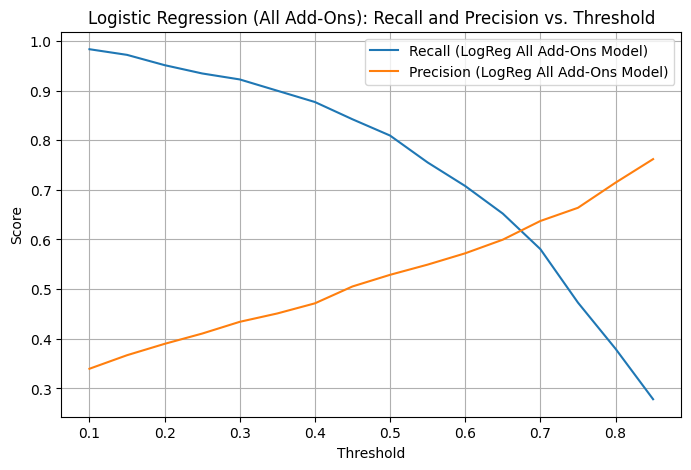

Logistic Regression (All Add-Ons) thresholds:
Threshold: 0.50, Recall: 0.80, Precision: 0.52
Threshold: 0.55, Recall: 0.76, Precision: 0.55
Threshold: 0.60, Recall: 0.71, Precision: 0.57


In [68]:
# Test probability thresholds for Logistic Regression All Add-Ons model

# Get out-of-fold predicted probabilities for the positive class
cv_pred_proba_logreg_all_add_ons = cross_val_predict(best_logreg_all_add_ons, X_train_all_add_ons, y_train, cv=5, method='predict_proba')[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
recalls_logreg_all_add_ons = []
precisions_logreg_all_add_ons = []

for thresh in thresholds:
    y_pred = (cv_pred_proba_logreg_all_add_ons >= thresh).astype(int)
    recalls_logreg_all_add_ons.append(recall_score(y_train, y_pred))
    precisions_logreg_all_add_ons.append(precision_score(y_train, y_pred))

plt.figure(figsize=(8,5))
plt.plot(thresholds, recalls_logreg_all_add_ons, label='Recall (LogReg All Add-Ons Model)')
plt.plot(thresholds, precisions_logreg_all_add_ons, label='Precision (LogReg All Add-Ons Model)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Logistic Regression (All Add-Ons): Recall and Precision vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()

# Print thresholds with recall ≥ 0.70 and precision ≥ 0.50
print('Logistic Regression (All Add-Ons) thresholds:')
for thresh, rec, prec in zip(thresholds, recalls_logreg, precisions_logreg):
    if rec >= 0.70 and prec >= 0.50:
        print(f"Threshold: {thresh:.2f}, Recall: {rec:.2f}, Precision: {prec:.2f}")



### Threshold Comparison Table: Recall and Precision for Logistic Regression All Add-Ons Model with recall >= 0.7 and precision >= 0.5 (Sorted by Threshold)
| Threshold | Recall | Precision |
|-----------|--------|-----------|
| 0.50      | 0.80   | 0.52      |
| 0.55      | 0.76   | 0.55      |
| 0.60      | 0.71   | 0.57      |


In [72]:
# Calculate confusion matrix for 0.5 threshold on training data for Logistic Regression All Add-Ons Model

best_logreg_all_add_ons.fit(X_train_all_add_ons, y_train)
y_proba_logreg_train = best_logreg_all_add_ons.predict_proba(X_train_all_add_ons)[:, 1]
y_pred_logreg_train = (y_proba_logreg_train >= 0.5).astype(int)
cm_logreg_train_all_add_ons = confusion_matrix(y_train, y_pred_logreg_train)
print("Confusion Matrix - Logistic Regression (All Add-Ons, 0.5 threshold, training data):\n", cm_logreg_train)





Confusion Matrix - Logistic Regression (All Add-Ons, 0.5 threshold, training data):
 [[3052 1078]
 [ 282 1213]]


In [73]:
# Confusion Matrix with Row_Wise Percentages
cm_log_reg_train_all_add_ons = confusion_matrix(y_train, y_pred_logreg_train)
cm_normalized = cm_logreg_train_all_add_ons.astype('float') / cm_logreg_train_all_add_ons.sum(axis=1)[:, np.newaxis]

cm_df_all_add_ons = pd.DataFrame(
    cm_normalized,
    index=['Actual Negative', 'Actual Positive'],
    columns=['Predicted Negative', 'Predicted Positive']
)

print('Row-normalized confusion matrix for All Add-Ons Model:')
display(cm_df)

Row-normalized confusion matrix:


,Predicted Negative,Predicted Positive
Actual Negative,0.738741,0.261259
Actual Positive,0.182609,0.817391


**Notes:**

Businesses typically aim to identify at least 70% of actual churners (recall ≥ 0.7) and prefer that at least half of the customers flagged as churners actually do churn (precision ≥ 0.5). I focused on the threshold that met these criteria, which is why the 0.5 probability threshold was selected for evaluation. 

In practice, the optimal model choice may depend on additional business factors, such as the relative costs of customer churn versus retention offers, which are not specified here.

## 6. Final Model Testing
- Retrain final model on entire training dataset using best hyperparameters and preprocessing
- Evaluate on untouched test set
- Report final metrics (recall, precision, ROC-AUC)


### Retrain Logistic Regression All Add-Ons model on full training data with best hyperparameters

In [83]:
# Best parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

final_logreg_all_add_ons = LogisticRegression(
    **internet_service_grid.best_params_,
    max_iter=1000,
    random_state=SEED
)
final_logreg_all_add_ons.fit(X_train_all_add_ons, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


### Predict on All Add-Ons test set and apply threshold

In [85]:
# Predictions on test set
X_test_all_add_ons = X_test_final_clean[pruned_features_all_add_ons]

y_pred_final_logreg_all_add_ons = final_logreg_all_add_ons.predict(X_test_all_add_ons)
y_proba_final_logreg_all_add_ons = final_logreg_all_add_ons.predict_proba(X_test_all_add_ons)[:, 1]


# Apply 0.5 threshold
y_pred_final_logreg_all_add_ons = (y_proba_final_logreg_all_add_ons >= 0.5).astype(int)

### Evaluate Internet Service Logistic Regression model on test set

In [86]:
# Compare predictions to true labels--All Add-Ons Model
recall_all_add_ons = recall_score(y_test, y_pred_final_logreg_all_add_ons)
precision_all_add_ons = precision_score(y_test, y_pred_final_logreg_all_add_ons)
roc_auc_all_add_ons = roc_auc_score(y_test, y_proba_final_logreg_all_add_ons)
cm_all_add_ons = confusion_matrix(y_test, y_pred_final_logreg_all_add_ons)

print(f"Recall Final All Add-Ons Model: {recall_all_add_ons:.3f}")
print(f"Precision Final All Add-Ons Model: {precision_all_add_ons:.3f}")
print(f"ROC-AUC Final All Add-Ons Model: {roc_auc_all_add_ons:.3f}")
print("Confusion Matrix Final All Add-Ons Model:")
print(cm_all_add_ons)

Recall Final All Add-Ons Model: 0.797
Precision Final All Add-Ons Model: 0.492
ROC-AUC Final All Add-Ons Model: 0.835
Confusion Matrix Final All Add-Ons Model:
[[725 308]
 [ 76 298]]


### Display row-normalized confusion matrix for All Add-Ons logistic regression model

In [87]:
def confusion_matrix_percentages(cm):
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    return pd.DataFrame(
        cm_pct,
        index=['Actual Negative', 'Actual Positive'],
        columns=['Predicted Negative', 'Predicted Positive']
    )

cm_pct_all_add_ons = confusion_matrix_percentages(cm_all_add_ons)

print("Confusion Matrix (% actual class, row-normalized) - Final All Add-Ons Logistic Regression (0.5 threshold, test set):")
display(cm_pct_all_add_ons)

Confusion Matrix (% actual class, row-normalized) - Final All Add-Ons Logistic Regression (0.5 threshold, test set):


,Predicted Negative,Predicted Positive
Actual Negative,70.183930,29.816070
Actual Positive,20.320856,79.679144


### Determine the most important features for final Internet Service logistic regression model

In [88]:
# Determine most important predictors for final Internet Service logistic regression model

# Get feature names and coefficients
feature_names_all_add_ons = X_train_all_add_ons.columns
coefs_all_add_ons = final_logreg_all_add_ons.coef_.flatten()

# Create DataFrame of features and coefficients
coef_df_all_add_ons = pd.DataFrame({
    'feature': feature_names_all_add_ons,
    'coefficient': coefs_all_add_ons,
    'abs_coefficient': np.abs(coefs_all_add_ons)
})

# Sort by absolute value of coefficient (importance)
coef_df_all_add_ons = coef_df_all_add_ons.sort_values('abs_coefficient', ascending=False)

# Display top 10 predictors
print("Top 10 important predictors for Final All Add-Ons Logistic Regression Model:")
print(coef_df_all_add_ons.head(10))

Top 10 important predictors for Final All Add-Ons Logistic Regression Model:
                           feature  coefficient  abs_coefficient
18               Contract_Two_year    -1.796906         1.796906
25            tenure_group_eng_49+    -1.691383         1.691383
24          tenure_group_eng_25-48    -1.486179         1.486179
23          tenure_group_eng_13-24    -1.129719         1.129719
4      InternetService_Fiber_optic     0.896278         0.896278
17               Contract_One_year    -0.873276         0.873276
26           tenure_group_eng_7-12    -0.765764         0.765764
21  PaymentMethod_Electronic_check     0.406199         0.406199
6               OnlineSecurity_Yes    -0.372610         0.372610
3   MultipleLines_No_phone_service     0.353136         0.353136


In [104]:
# Print top 10 positive predictors of churn
print("Top 10 positive predictors of churn (Final All Add-Ons Logistic Regression Model):")
print(coef_df_all_add_ons[['feature', 'coefficient']].sort_values('coefficient', ascending=False).head(10))

Top 10 positive predictors of churn (Final All Add-Ons Logistic Regression Model):
                                  feature  coefficient
4             InternetService_Fiber_optic     0.896278
21         PaymentMethod_Electronic_check     0.406199
3          MultipleLines_No_phone_service     0.353136
14                        StreamingTV_Yes     0.322166
16                    StreamingMovies_Yes     0.313710
19                   PaperlessBilling_Yes     0.264120
0                       SeniorCitizen_Yes     0.213023
20  PaymentMethod_Credit_card_(automatic)     0.073304
10                   DeviceProtection_Yes     0.041392
22             PaymentMethod_Mailed_check     0.032000


In [105]:
# Display top 10 negative predictors of churn
print("Top 10 negative predictors of churn (Final All Add-Ons Logistic Regression Model):")
print(coef_df_all_add_ons[['feature', 'coefficient']].sort_values('coefficient').head(10))

Top 10 negative predictors of churn (Final All Add-Ons Logistic Regression Model):
                   feature  coefficient
18       Contract_Two_year    -1.796906
25    tenure_group_eng_49+    -1.691383
24  tenure_group_eng_25-48    -1.486179
23  tenure_group_eng_13-24    -1.129719
17       Contract_One_year    -0.873276
26   tenure_group_eng_7-12    -0.765764
6       OnlineSecurity_Yes    -0.372610
12         TechSupport_Yes    -0.319434
2           Dependents_Yes    -0.206124
8         OnlineBackup_Yes    -0.178825


In [101]:
# Load the column manifest with readable labels
manifest = pd.read_csv('../references/telco_column_role_manifest_with_labels.csv')

# Create a mapping: feature code → readable label
# Adjust column names as needed based on your manifest structure
feature_map = dict(zip(manifest['column_name'], manifest['readable_label']))

# Map features in coef_df to readable labels
coef_df_all_add_ons['readable_label'] = coef_df_all_add_ons['feature'].map(feature_map).fillna(coef_df_all_add_ons['feature'])

# Display top predictors with readable labels
print(coef_df_all_add_ons[['readable_label', 'coefficient', 'abs_coefficient']].head(10))

                     readable_label  coefficient  abs_coefficient
18                Contract_Two_year    -1.796906         1.796906
25        Tenure Group (49+ months)    -1.691383         1.691383
24      Tenure Group (25-48 months)    -1.486179         1.486179
23     Tenure Group (13-24  months)    -1.129719         1.129719
4    Internet Service (Fiber Optic)     0.896278         0.896278
17            Contract 1-year (Yes)    -0.873276         0.873276
26       Tenure Group (7-12 months)    -0.765764         0.765764
21  Payment Method Electronic (Yes)     0.406199         0.406199
6             Online Security (Yes)    -0.372610         0.372610
3              Multiple Lines (Yes)     0.353136         0.353136


/var/folders/xk/1_94y7fn37sf7kbch2g77hlm0000gp/T/ipykernel_61405/1497697350.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='coefficient', y='readable_label', data=top_coef, palette='coolwarm', orient='h')


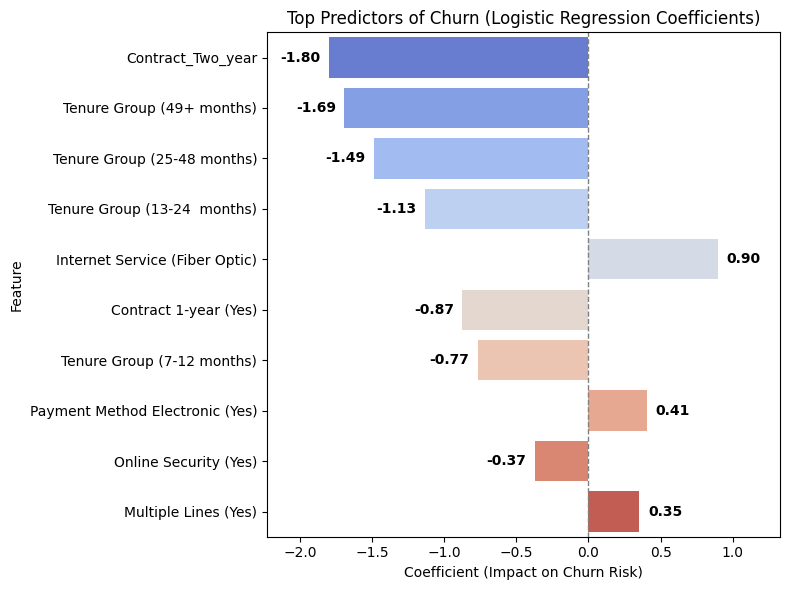

In [106]:
# Plot top predictors for churn from logistic regression model

top_n = 10
top_coef = coef_df_all_add_ons.head(top_n).copy()
plt.figure(figsize=(8, 6))  # Wide figure for more space
ax = sns.barplot(x='coefficient', y='readable_label', data=top_coef, palette='coolwarm', orient='h')
plt.title('Top Predictors of Churn (Logistic Regression Coefficients)')
plt.xlabel('Coefficient (Impact on Churn Risk)')
plt.ylabel('Feature')
plt.axvline(0, color='gray', linestyle='--', linewidth=1)

# Set x-limits to add more space for annotation text
xlim = ax.get_xlim()
x_pad = 0.1 * (xlim[1] - xlim[0])
plt.xlim(xlim[0] - x_pad, xlim[1] + x_pad)

# Annotate each bar with its coefficient value, always outside the bar
for bar, coef in zip(ax.patches, top_coef['coefficient']):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    if x >= 0:
        text_x = x + 0.02 * (xlim[1] - xlim[0])
        ha = 'left'
    else:
        text_x = x - 0.02 * (xlim[1] - xlim[0])
        ha = 'right'
    ax.text(text_x, y, f'{coef:.2f}', va='center', ha=ha, color='black', fontsize=10, fontweight='bold', clip_on=False)

plt.tight_layout()
plt.show()

### Comparison of Validation and Test Set Performance for Final Logistic Regression Model

The table below summarizes key metrics at the 0.50 probability threshold, comparing the model’s performance on the validation set (cross-validated training data) to its performance on the holdout test set after retraining on the full training data. This allows for an assessment of model generalization and consistency across data splits.

**Note on terminology:**
- The "validation set" refers to the portion of the training data used during cross-validation to tune hyperparameters and select the best model. These results reflect model performance during development, before seeing the test set.
- The "test set" (also called the holdout set) is a separate, untouched dataset set aside at the start of the project. It is only used for the final evaluation after all model selection and tuning are complete, providing an unbiased estimate of real-world performance.


| Metric                                | Validation Set | Test Set |
|---------------------------------------|----------------|----------|
|Recall                                 | 0.8094            | 0.797     |
|Precision                              | 0.5290            | 0.492     |
|ROC-AUC                                | 0.8469           | 0.835    |
|Confusion Matrix (% of actual class)   |                 |          |
|    - True Neg (TN)                    | 73.9           | 70.18      |
|    - False Pos (FP)                   | 26.1           | 29.82      |
|    - False Neg (FN)                   | 18.26           | 20.32      |
|    - True Pos (TP)                    | 81.74           | 79.68      |

**Summary**:
- The model generalizes well—there’s no sign of severe overfitting.
- The small drop in precision and recall is expected when moving from validation to test data.
- These differences are minor and within the range of normal variation.


| Rank | All Features Model              | Coeff | Abs(Coeff) | Internet Service Model         | Coeff | Abs(Coeff) |
|------|-------------------------------------|-------------|------------------|----------------------------------|-------------|------------------|
| 1    | Contract_Two_year                   | -0.86       | 0.86             | Contract_Two_year                | -1.89       | 1.89             |
| 2    | tenure                              | -0.62       | 0.62             | tenure_group_eng_49+             | -1.74       | 1.74             |
| 3    | is_month_to_month_eng_Yes           |  0.61       | 0.61             | MonthlyCharges                   |  1.66       | 1.66             |
| 4    | PhoneService_Yes                    | -0.55       | 0.55             | tenure_group_eng_25-48           | -1.51       | 1.51             |
| 5    | tenure_group_eng_7-12               | -0.54       | 0.54             | MultipleLines_No_phone_service   |  1.19       | 1.19             |
| 6    | short_tenure_month_to_month_eng_True|  0.53       | 0.53             | tenure_group_eng_13-24           | -1.15       | 1.15             |
| 7    | InternetService_Fiber_optic         |  0.49       | 0.49             | Contract_One_year                | -0.91       | 0.91             |
| 8    | OnlineSecurity_Yes                  | -0.46       | 0.46             | tenure_group_eng_7-12            | -0.77       | 0.77             |
| 9    | TechSupport_Yes                     | -0.43       | 0.43             | total_services_eng               | -0.67       | 0.67             |
| 10   | PaymentMethod_Electronic_check      |  0.35       | 0.35             | PaymentMethod_Electronic_check   |  0.44       | 0.44             |

**Note:** Coefficient values are rounded to two decimal places for clarity. Negative coefficients indicate features associated with lower churn probability, while positive coefficients indicate higher churn risk.